### **Yogyakarta's Air Quality Dataset in May 2021**

In [2]:
import pandas as pd

df = pd.read_csv("05-jogja-may-2021.csv")
print(df.shape)  # (jumlah baris, jumlah kolom)
df.index = df.index + 1
df.head(744)

(744, 11)


,Date,Time,PM10,PM2.5,SO2,CO,O3,NO2,Max,Critical Component,Category
1,5/1/2021,00:00:00,22,53,17,12,NaN,4,53,PM2.5,Moderate
2,5/1/2021,01:00:00,22,52,17,12,NaN,4,52,PM2.5,Moderate
3,5/1/2021,02:00:00,21,52,17,12,NaN,4,52,PM2.5,Moderate
4,5/1/2021,03:00:00,22,52,17,12,NaN,4,52,PM2.5,Moderate
5,5/1/2021,04:00:00,22,53,17,12,NaN,4,53,PM2.5,Moderate
...,...,...,...,...,...,...,...,...,...,...,...
740,5/31/2021,19:00:00,21,50,19,9,21.0,6,50,PM2.5,Good
741,5/31/2021,20:00:00,21,50,20,9,19.0,6,50,PM2.5,Good
742,5/31/2021,21:00:00,20,50,20,9,17.0,5,50,PM2.5,Good
743,5/31/2021,22:00:00,20,49,20,8,15.0,5,49,PM2.5,Good


#### <span style="color:blue">**Data Quality Check**</span>

In [3]:
filename = "05-jogja-may-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df.info()                 # tipe data setiap kolom
df.isna().sum()           # jumlah data kosong per kolom
df.duplicated().sum()     # jumlah baris duplikat

Data source: 05-jogja-may-2021.csv
<class 'pandas.DataFrame'>
RangeIndex: 744 entries, 0 to 743
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                744 non-null    str    
 1   Time                744 non-null    str    
 2   PM10                744 non-null    int64  
 3   PM2.5               744 non-null    int64  
 4   SO2                 744 non-null    int64  
 5   CO                  744 non-null    int64  
 6   O3                  498 non-null    float64
 7   NO2                 744 non-null    int64  
 8   Max                 744 non-null    int64  
 9   Critical Component  744 non-null    str    
 10  Category            744 non-null    str    
dtypes: float64(1), int64(6), str(4)
memory usage: 64.1 KB


np.int64(0)

#### <span style="color:blue">**Descriptive Statistics for Numerical Variables**</span>

In [4]:
filename = "05-jogja-may-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
kolom = df["PM2.5"]
kolom.mean(), kolom.median(), kolom.mode()[0]
kolom.var(), kolom.std()
kolom.quantile(0.25), kolom.quantile(0.75)
df.describe()

Data source: 05-jogja-may-2021.csv


,PM10,PM2.5,SO2,CO,O3,NO2,Max
count,744.000000,744.000000,744.000000,744.000000,498.000000,744.000000,744.000000
mean,24.138441,54.159946,17.251344,8.466398,35.524096,5.043011,54.422043
std,5.780733,5.873494,2.978613,2.949818,12.889736,1.125158,5.956265
min,13.000000,36.000000,11.000000,3.000000,10.000000,3.000000,36.000000
25%,20.000000,51.000000,15.000000,6.000000,24.000000,4.000000,51.000000
50%,22.000000,53.000000,18.000000,8.000000,37.000000,5.000000,54.000000
75%,28.000000,58.000000,20.000000,10.000000,46.000000,6.000000,59.000000
max,41.000000,69.000000,24.000000,18.000000,63.000000,8.000000,69.000000


#### <span style="color:blue">**Summary of Categorical Variables**</span>

##### <span style="color:blue">**1. Critical Component**</span>

In [5]:
filename = "05-jogja-may-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df["Critical Component"].value_counts() # Display the raw counts for each
df["Critical Component"].value_counts(normalize=True) * 100 # Display the percentages for each

Data source: 05-jogja-may-2021.csv


Critical Component
PM2.5    95.430108
O3        4.569892
Name: proportion, dtype: float64

##### <span style="color:blue">**2. Category**</span>

In [6]:
filename = "05-jogja-may-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df["Category"].value_counts() # Display the raw counts for each
df["Category"].value_counts(normalize=True) * 100 # Display the percentages for each

Data source: 05-jogja-may-2021.csv


Category
Moderate    77.956989
Good        22.043011
Name: proportion, dtype: float64

#### <span style="color:blue">**Data Visualization**</span>

##### <span style="color:blue">**1. Line Graph**</span>

Data source: 05-jogja-may-2021.csv


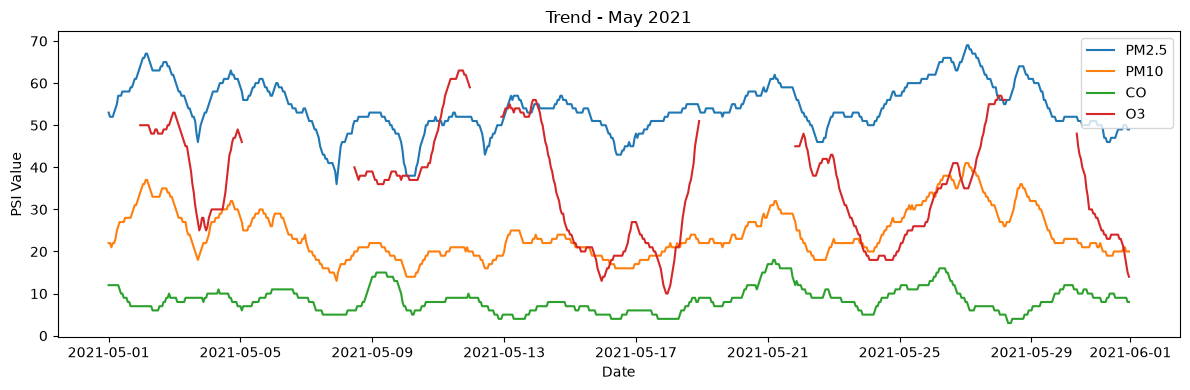

In [8]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "05-jogja-may-2021.csv"
df = pd.read_csv(filename) # Read the CSV file for the May data
print(f"Data source: {filename}") # Display  the file being used

numeric_cols = ["PM2.5", "PM10", "CO", "O3"] # List the columns that will be compared

# Combine Date and Time into one "datetime" column, so the x-axis is ordered correctly
df["Date_Time"] = pd.to_datetime(df["Date"] + " " + df["Time"]) # Merge date and time into one column

plt.figure(figsize=(12, 4)) # Adjust the chart size (width 12, height 4)
for col in numeric_cols:
    plt.plot(df["Date_Time"], df[col], label=col) # Draw one line per column and give the label for each
    
plt.title("Trend - May 2021") # Title for the chart
plt.xlabel("Date") # x-axis label
plt.ylabel("PSI Value") # y-axis label
plt.legend() # A small labeled box that tells what each color and line represents
plt.xticks(rotation=0) # Tilt "or not" the data labels to prevent overlapping
plt.tight_layout() # Adjust the spacing so that the label doesn't get cut off
plt.show() # Display the chart

**In May 2021, PM2.5 stayed the highest most of the month (roughly 40-70), O3 swung wildly up and down with several sharp drops and spikes, and PM10 and CO stayed low and steady throughout.**

##### <span style="color:blue">**2. Boxplot**</span>

Data source: 05-jogja-may-2021.csv


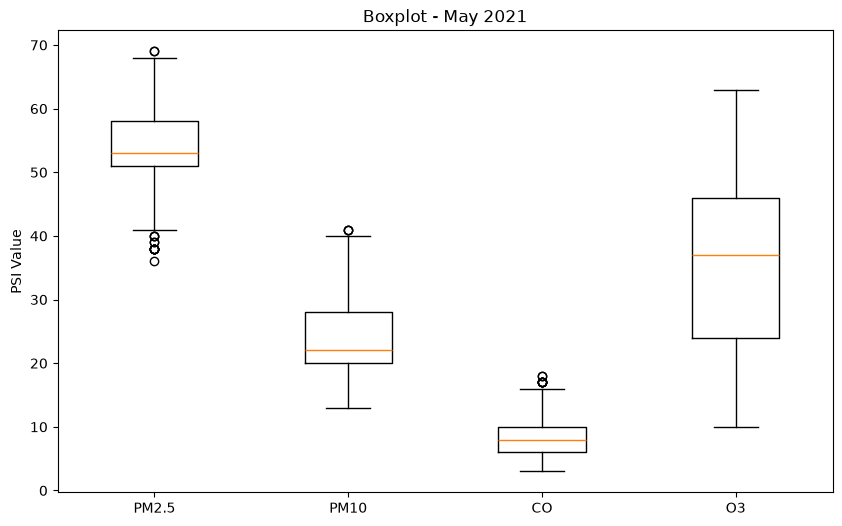

In [9]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "05-jogja-may-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

numeric_cols = ["PM2.5", "PM10", "CO", "O3"]

plt.figure(figsize=(10, 6))
plt.boxplot([df[col].dropna() for col in numeric_cols], tick_labels=numeric_cols)
plt.title("Boxplot - May 2021")
plt.ylabel("PSI Value")
plt.show()

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

**In May 2021, PM2.5 had the highest median (53) with some outliers, PM10 and CO had only a few outliers, and O3 had no outliers but spread out the most.**

##### <span style="color:blue">**3. Bar Chart**</span>

Data source: 05-jogja-may-2021.csv


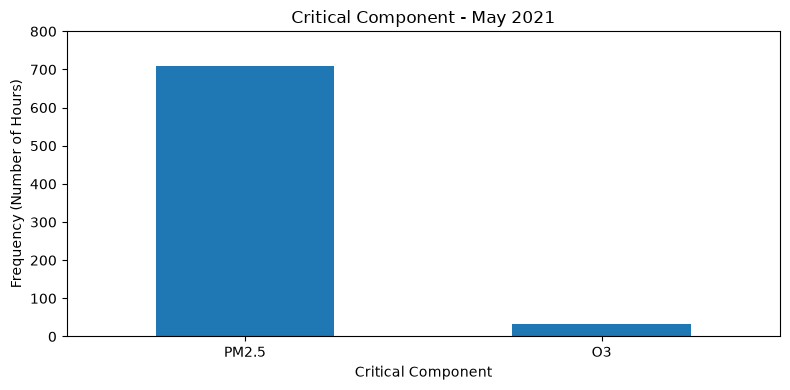

Critical Component
PM2.5    710
O3        34
Name: count, dtype: int64

In [10]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "05-jogja-may-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

# Bar chart for the "Critical Component" column
plt.figure(figsize=(8, 4))
df["Critical Component"].value_counts().plot(kind="bar")
plt.title("Critical Component - May 2021")
plt.xlabel("Critical Component")
plt.ylabel("Frequency (Number of Hours)")
plt.ylim(0, 800)  # Limit the y-axis from 0 to 800
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

df["Critical Component"].value_counts()  # Display the counts for each bar of Critical Component

**In May 2021, PM2.5 was the critical component almost all month (710 hours), while O3 only briefly took over for 34 hours, as no other pollutant was ever the main driver.**

Data source: 05-jogja-may-2021.csv


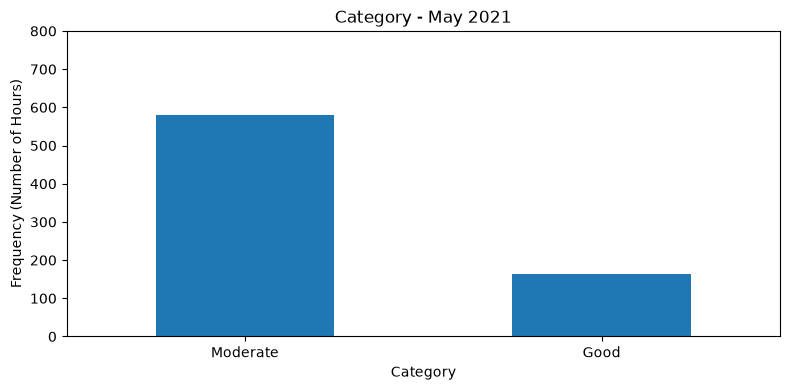

Category
Moderate    580
Good        164
Name: count, dtype: int64

In [11]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "05-jogja-may-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

#Bar chart for the "Category" column
plt.figure(figsize=(8, 4))
df["Category"].value_counts().plot(kind="bar")
plt.title("Category - May 2021")
plt.xlabel("Category")
plt.ylabel("Frequency (Number of Hours)")
plt.ylim(0, 800) # Limit the y-axis from 0 to 800
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

df["Category"].value_counts() # Display the counts for each category